In [29]:
import matplotlib
print(matplotlib.__version__)

import matplotlib.pyplot as plt
print("Matplotlib works!")

3.11.1
Matplotlib works!


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Part 1: Understanding the Dataset

In [ ]:
#Load the dataset
df = pd.read_csv("./data/insurance.csv")

In [32]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Display first 10 rows
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
129,38,1,34.70,2,0,3,6082.40500
571,18,0,37.29,1,0,2,2219.44510
72,53,0,28.10,3,0,3,11741.72600
784,31,0,29.26,1,0,2,4350.51440
1141,41,0,32.60,3,0,3,7954.51700
736,37,0,38.39,0,1,2,40419.01910
1211,39,1,34.10,2,0,2,23563.01618
496,31,0,23.60,2,0,3,4931.64700
1152,43,0,32.56,3,1,2,40941.28540
502,51,1,23.21,1,1,2,22218.11490


In [54]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (1338, 7)


In [33]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [37]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [55]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Features:")
print(numerical_features)

Numerical Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


In [56]:
categorical_features = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical_features)

Categorical Features:
Index([], dtype='str')


In [38]:
print(df["sex"].unique())
print(df["smoker"].unique())
print(df["region"].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [39]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

In [40]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [41]:
X = df.drop("charges", axis=1)

In [42]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


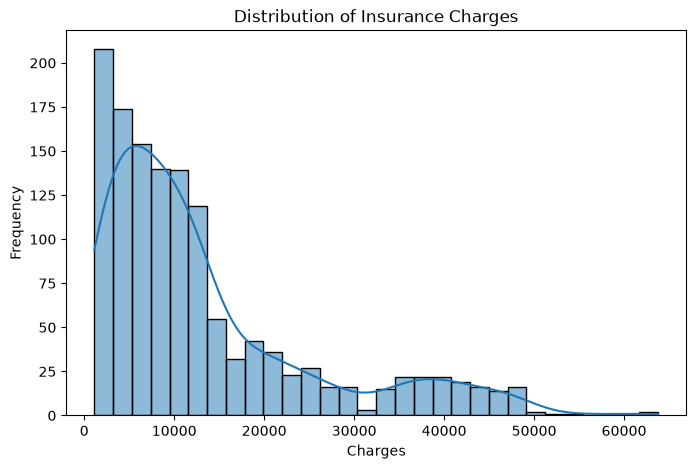

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

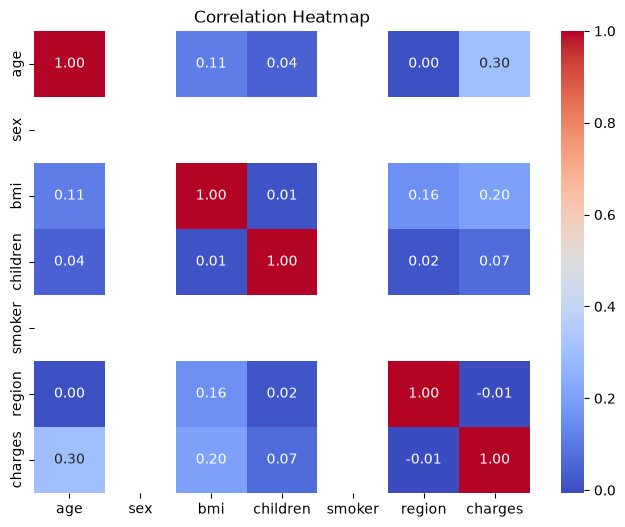

In [58]:
df_encoded = df.copy()

df_encoded["sex"] = df_encoded["sex"].map({"female":0,"male":1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no":0,"yes":1})
df_encoded["region"] = df_encoded["region"].astype("category").cat.codes
plt.figure(figsize=(8,6))

sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()


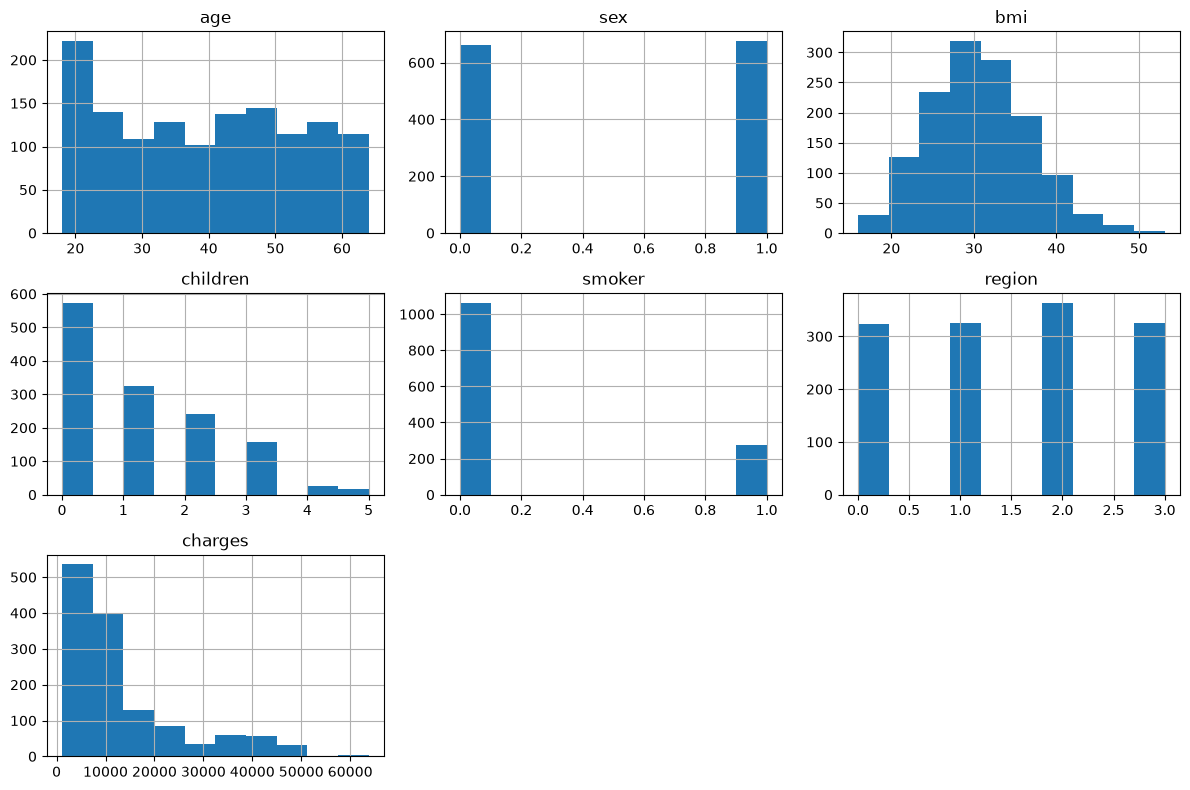

In [59]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

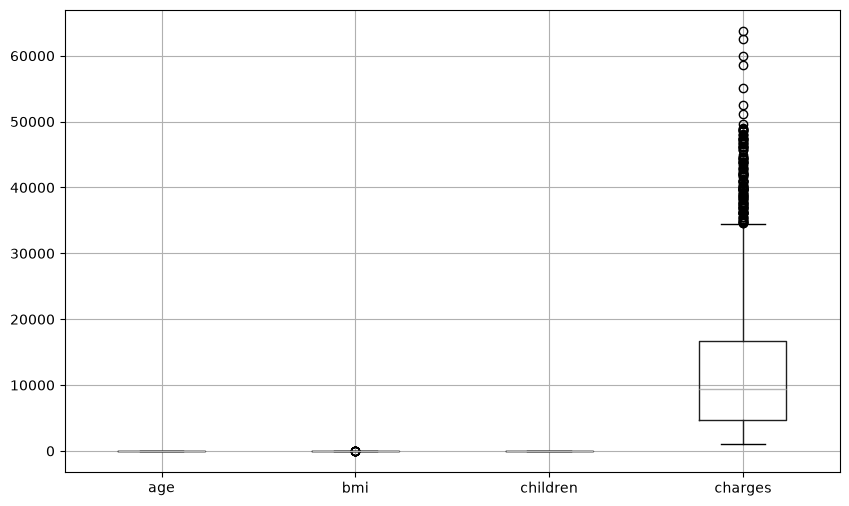

In [60]:
numeric_columns = ["age","bmi","children","charges"]

plt.figure(figsize=(10,6))

df[numeric_columns].boxplot()

plt.show()

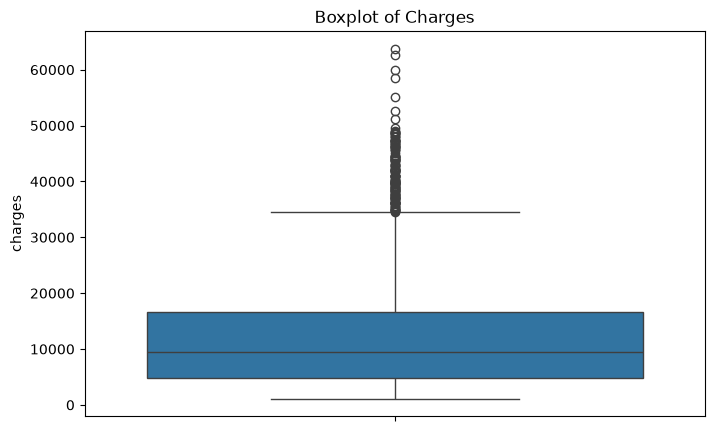

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["charges"])

plt.title("Boxplot of Charges")

plt.show()

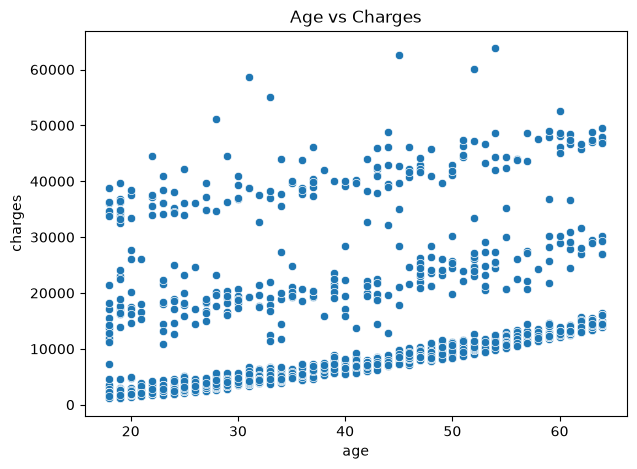

In [62]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="age",
                y="charges",
                data=df)

plt.title("Age vs Charges")

plt.show()

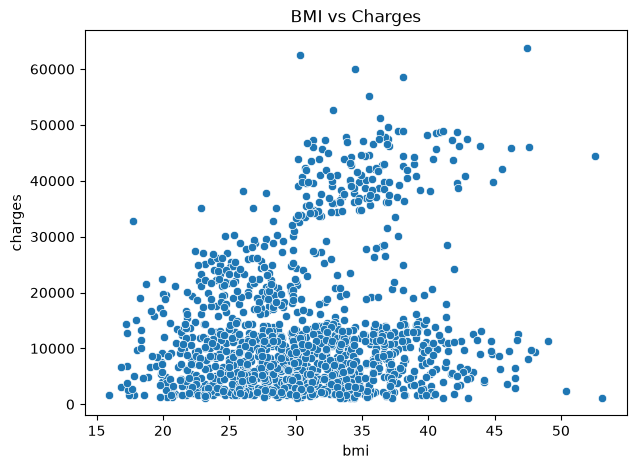

In [63]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="bmi",
                y="charges",
                data=df)

plt.title("BMI vs Charges")

plt.show()

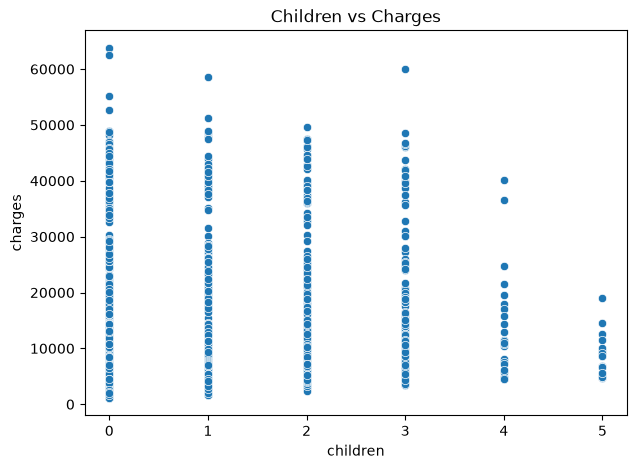

In [64]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="children",
                y="charges",
                data=df)

plt.title("Children vs Charges")

plt.show()

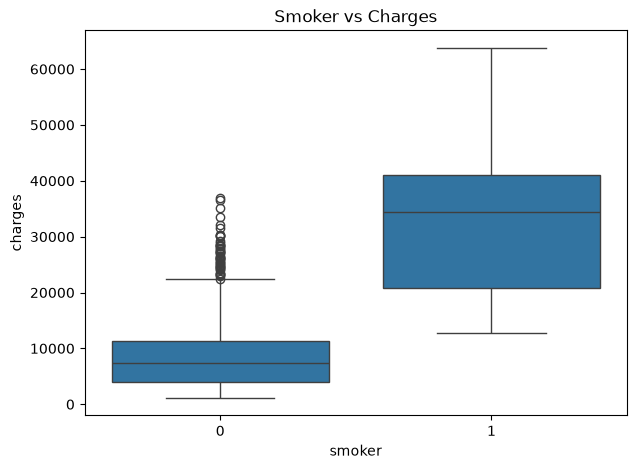

In [65]:
plt.figure(figsize=(7,5))

sns.boxplot(x="smoker",
            y="charges",
            data=df)

plt.title("Smoker vs Charges")

plt.show()

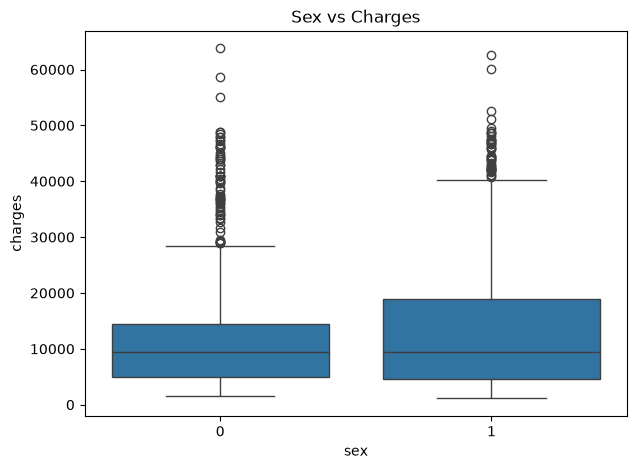

In [66]:
plt.figure(figsize=(7,5))

sns.boxplot(x="sex",
            y="charges",
            data=df)

plt.title("Sex vs Charges")

plt.show()

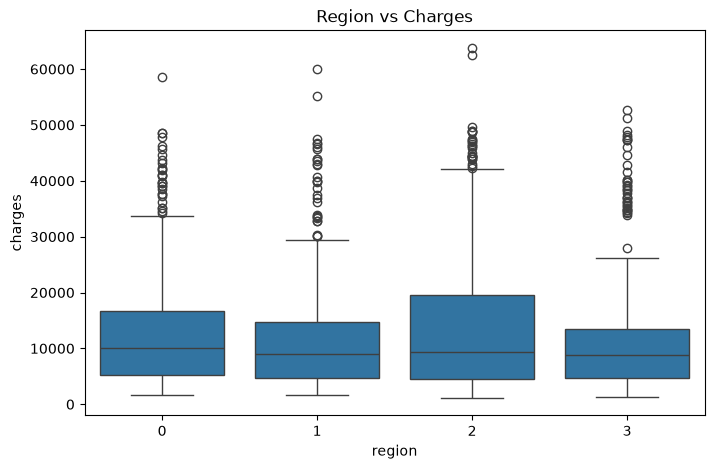

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(x="region",
            y="charges",
            data=df)

plt.title("Region vs Charges")

plt.show()

In [68]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["charges"] < lower_limit) |
    (df["charges"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 139


In [69]:
outliers.head()

,age,sex,bmi,children,smoker,region,charges
14,27,1,42.13,0,1,2,39611.7577
19,30,1,35.30,0,1,3,36837.4670
23,34,0,31.92,1,1,0,37701.8768
29,31,1,36.30,2,1,3,38711.0000
30,22,1,35.60,0,1,3,35585.5760


In [44]:
X = df[["age","sex","bmi","children","smoker","region"]]

In [17]:
y = df["charges"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 257.06, -18.79, 335.78, 425.09,23647.82, -271.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.195e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [21]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 2.57056264e+02 -1.87914567e+01  3.35781491e+02  4.25091456e+02
  2.36478181e+04 -2.71284266e+02]
Intercept: -11946.606567263034


In [22]:
y_pred = model.predict(X_test)

In [23]:
comparison = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": y_pred
})

print(comparison.head())

      Actual Charges  Predicted Charges
764       9095.06825        8924.407244
887       5272.17580        7116.295018
890      29330.98315       36909.013521
1293      9301.89355        9507.874691
259      33750.29180       27013.350008


In [24]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 33635210.431178406


In [25]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5799.587091438356


In [26]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7833463107364539


In [ ]:
#Suppose a customer has:

#Age = 30
#Sex = Male
#BMI = 25
#Children = 2
#Smoker = No
#Region = Northwest on the encoder we took 1 for the region

new_customer = [[30, 1, 25.0, 2, 0, 1]]

prediction = model.predict(new_customer)

print("Predicted Charges:", prediction)

Predicted Charges: [4719.72580613]
